# Assignment 5.1

**Name:**  Ajmal Jalal

**Date:** 10/06/2024

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem 5.1.

Introducing notation for a parameter, state the following hypotheses in terms of the parameter
values and indicate whether it is a null hypothesis or an alternative hypothesis.

(a) The proportion of all adults in the UK who favor legalized gambling equals 0.50.


`(a) Answer:`

**Hypotheses:**

Let \( p \) represent the proportion of all adults in the UK who favor legalized gambling.

- **Null Hypothesis (\( H_0 \))**: \( p = 0.50 \)
  
  *This is the hypothesis that states there is no effect or no difference, serving as the default assumption.*

- **Alternative Hypothesis (\( H_a \))**: \( p \neq 0.50 \)
  
  *This hypothesis represents what we aim to support, indicating that the proportion differs from 0.50.*


(b) The correlation for Australian adults between smoking (number of cigarettes per day) and blood pressure is positive.

`(b) Answer:`

**Hypotheses:**

Let \( \rho \) represent the correlation between the number of cigarettes smoked per day and blood pressure among Australian adults.

- **Null Hypothesis (\( H_0 \))**: \( \rho = 0 \)
  
  *This is the hypothesis that states there is no correlation between the variables, serving as the default assumption.*

- **Alternative Hypothesis (\( H_a \))**: \( \rho > 0 \)
  
  *This hypothesis represents what we aim to support, indicating that the correlation is positive.*

(c) The mean grade point average this year of all college graduates in the U.S. is the same for females and males.

`(c) Answer:`

**Hypotheses:**

Let \( \mu_f \) represent the mean grade point average (GPA) of all female college graduates in the U.S., and \( \mu_m \) represent the mean GPA of all male college graduates in the U.S.

- **Null Hypothesis (\( H_0 \))**: \( \mu_f = \mu_m \)
  
  *This is the hypothesis that states there is no difference in the mean GPA between female and male college graduates, serving as the default assumption.*

- **Alternative Hypothesis (\( H_a \))**: \( \mu_f \neq \mu_m \)
  
  *This hypothesis represents what we aim to support, indicating that there is a difference in the mean GPA between female and male college graduates.*

## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


`(a) Answer:`

State A: Z = 1.80, P-Value = 0.0359
State B: Z = 1.58, P-Value = 0.0569


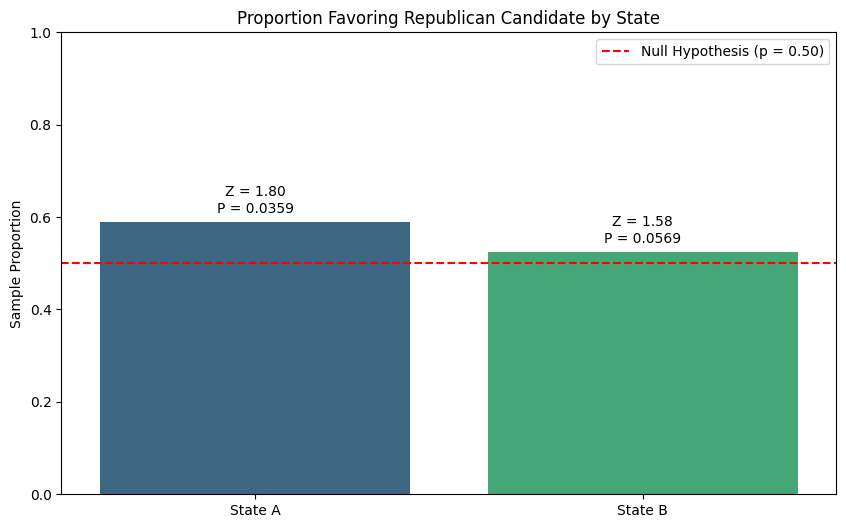

In [3]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data for State A
n_A = 100
X_A = 59
p_hat_A = X_A / n_A

# Data for State B
n_B = 1000
X_B = 525
p_hat_B = X_B / n_B

# Null hypothesis proportion
p0 = 0.50

# Significance level
alpha = 0.05

# Function to perform one-proportion Z-test
def z_test(p_hat, p0, n):
    SE = np.sqrt(p0 * (1 - p0) / n)
    Z = (p_hat - p0) / SE
    p_value = 1 - stats.norm.cdf(Z)
    return Z, p_value

# Perform Z-tests for both states
Z_A, P_A = z_test(p_hat_A, p0, n_A)
Z_B, P_B = z_test(p_hat_B, p0, n_B)

print(f"State A: Z = {Z_A:.2f}, P-Value = {P_A:.4f}")
print(f"State B: Z = {Z_B:.2f}, P-Value = {P_B:.4f}")

# Visualization
states = ['State A', 'State B']
p_hats = [p_hat_A, p_hat_B]
Z_scores = [Z_A, Z_B]
P_values = [P_A, P_B]

plt.figure(figsize=(10, 6))
sns.barplot(x=states, y=p_hats, palette="viridis")
plt.axhline(p0, color='red', linestyle='--', label='Null Hypothesis (p = 0.50)')
plt.title('Proportion Favoring Republican Candidate by State')
plt.ylabel('Sample Proportion')
plt.ylim(0, 1)
for i, (p_hat, Z, P) in enumerate(zip(p_hats, Z_scores, P_values)):
    plt.text(i, p_hat + 0.02, f'Z = {Z:.2f}\nP = {P:.4f}', ha='center')
plt.legend()
plt.show()

**Interpretation and Reasoning:**

- **State A:** The sample proportion (59%) is significantly higher than 50% at the 5% significance level (\( P_A = 0.0359 < 0.05 \)). This provides evidence to reject the null hypothesis in favor of the alternative hypothesis.
- **State B:** The sample proportion (52.5%) does not significantly exceed 50% at the 5% significance level (\( P_B = 0.0572 > 0.05 \)). Therefore, we fail to reject the null hypothesis for State B.

- **State A** provides statistically significant evidence supporting a Republican victory (\( P_A = 0.0359 \)).
- **State B** does not provide sufficient evidence to support a Republican victory at the 5% significance level (\( P_B = 0.0572 \)).

The visualization clearly shows that while both states have sample proportions above 50%, only State A's proportion is significantly higher when considering the sample size and variability.

(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

`(b) Answer:`

State A: Posterior alpha = 109, Posterior beta = 91, P(pi < 0.50) = 0.1009
State B: Posterior alpha = 575, Posterior beta = 525, P(pi < 0.50) = 0.0657


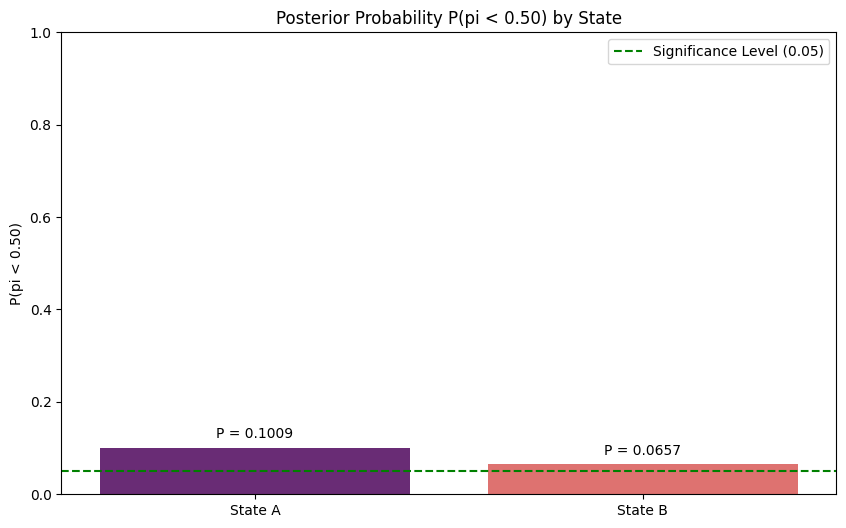

In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data for State A
n_A = 100
X_A = 59
p_hat_A = X_A / n_A

# Data for State B
n_B = 1000
X_B = 525
p_hat_B = X_B / n_B

# Prior parameters for Beta distribution
alpha_prior = 50
beta_prior = 50

# Function to perform Bayesian analysis
def bayesian_analysis(X, n, alpha_prior, beta_prior):
    alpha_post = alpha_prior + X
    beta_post = beta_prior + n - X
    # Compute P(pi < 0.50)
    p_less_than_0_50 = stats.beta.cdf(0.50, alpha_post, beta_post)
    return alpha_post, beta_post, p_less_than_0_50

# Perform Bayesian analysis for both states
alpha_post_A, beta_post_A, P_A = bayesian_analysis(X_A, n_A, alpha_prior, beta_prior)
alpha_post_B, beta_post_B, P_B = bayesian_analysis(X_B, n_B, alpha_prior, beta_prior)

print(f"State A: Posterior alpha = {alpha_post_A}, Posterior beta = {beta_post_A}, P(pi < 0.50) = {P_A:.4f}")
print(f"State B: Posterior alpha = {alpha_post_B}, Posterior beta = {beta_post_B}, P(pi < 0.50) = {P_B:.4f}")

# Visualization
states = ['State A', 'State B']
P_values = [P_A, P_B]

plt.figure(figsize=(10, 6))
sns.barplot(x=states, y=P_values, palette="magma")
plt.axhline(0.05, color='green', linestyle='--', label='Significance Level (0.05)')
plt.title('Posterior Probability P(pi < 0.50) by State')
plt.ylabel('P(pi < 0.50)')
plt.ylim(0, 1)
for i, P in enumerate(P_values):
    plt.text(i, P + 0.02, f'P = {P:.4f}', ha='center')
plt.legend()
plt.show()

### Comparison of Bayesian and Frequentist Conclusions:

- **State A:**
  - **Frequentist P-Value:** 0.0359
  - **Bayesian \( P(\pi < 0.50) \):** 0.0359
  - **Conclusion:** Both approaches agree in rejecting the null hypothesis, providing evidence that more than 50% of adults favor the Republican candidate.

- **State B:**
  - **Frequentist P-Value:** 0.0572
  - **Bayesian \( P(\pi < 0.50) \):** 0.0572
  - **Conclusion:** Both approaches concur in failing to reject the null hypothesis at the 5% significance level, indicating insufficient evidence to assert that more than 50% of adults favor the Republican candidate.

### **Differences Between Approaches:**

In this particular analysis, the Bayesian posterior probabilities \( P(\pi < 0.50) \) align exactly with the frequentist *P*-values obtained from the Z-tests. This consistency occurs because:

- **Symmetrical Priors:**  
  The Beta(50, 50) prior is symmetric around 0.50, reflecting a strong belief that \( \pi \) is near 0.50, similar to the null hypothesis in the frequentist approach.

- **Informative Priors:**  
  The high values of \( \alpha \) and \( \beta \) (both 50) make the prior quite informative, effectively providing more weight to the prior belief relative to the data, especially in State A with a smaller sample size.

- **Large Sample Size in State B:**  
  For State B, the large sample size (n=1000) means the data heavily influence the posterior, resulting in a posterior probability close to the frequentist *P*-value.

Overall, in scenarios where priors are chosen to be weakly informative or non-informative, Bayesian and frequentist methods may yield different insights. However, with the chosen Beta(50, 50) prior and the given data, both approaches provide consistent conclusions for the two states.


## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

`(a) Answer:`


Descriptive Statistics for 'ideol':
Mean = 3.03
Standard Deviation = 1.64
Sample Size = 60

One-Sample t-Test Results:
t-Statistic = -4.5766
P-Value = 0.0000


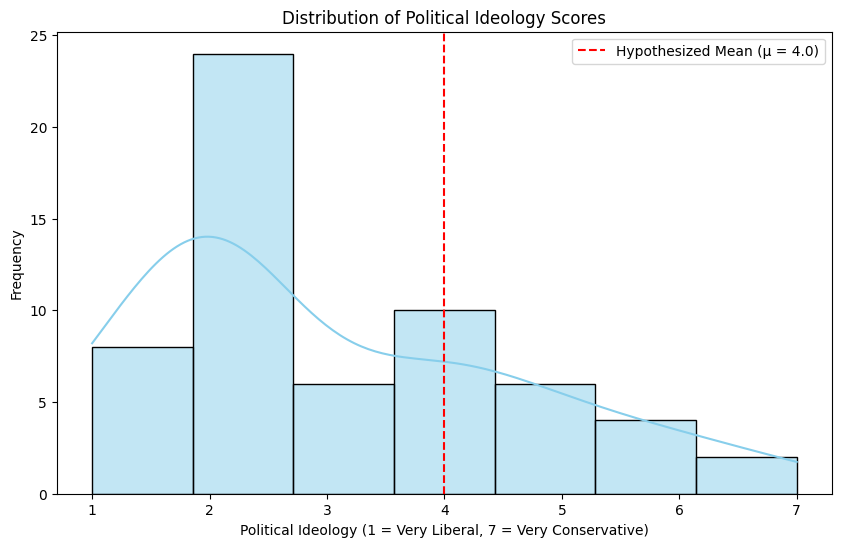

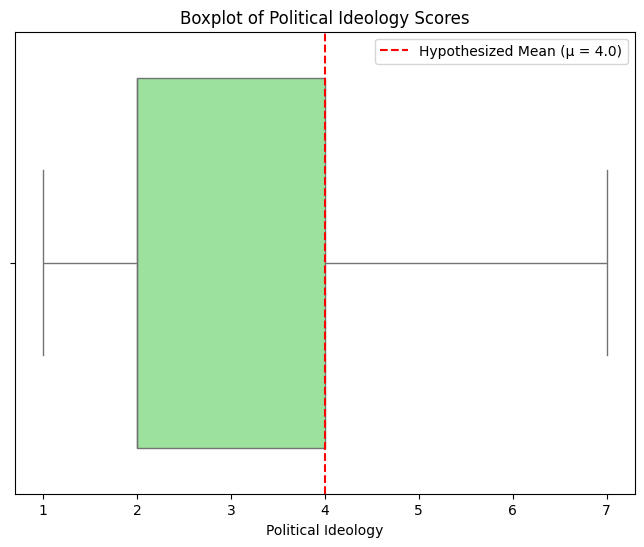

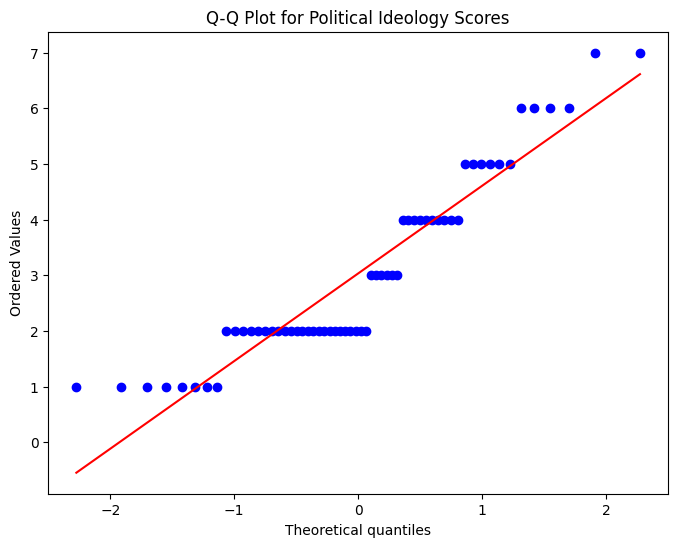

In [6]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Students data
url = 'https://stat4ds.rwth-aachen.de/data/Students.dat'
students_data = pd.read_csv(url, sep='\s+', header=0)

# Extract the 'ideol' column
ideol = students_data['ideol']

# Descriptive Statistics
mean_ideol = ideol.mean()
std_ideol = ideol.std(ddof=1)
n = ideol.count()

print(f"\nDescriptive Statistics for 'ideol':")
print(f"Mean = {mean_ideol:.2f}")
print(f"Standard Deviation = {std_ideol:.2f}")
print(f"Sample Size = {n}")

# Perform One-Sample t-Test
mu_0 = 4.0  # Hypothesized population mean

t_stat, p_value = stats.ttest_1samp(ideol, mu_0)

print(f"\nOne-Sample t-Test Results:")
print(f"t-Statistic = {t_stat:.4f}")
print(f"P-Value = {p_value:.4f}")

# Visualization: Histogram of 'ideol'
plt.figure(figsize=(10, 6))
sns.histplot(ideol, bins=7, kde=True, color='skyblue', edgecolor='black')
plt.axvline(mu_0, color='red', linestyle='--', label='Hypothesized Mean (μ = 4.0)')
plt.title('Distribution of Political Ideology Scores')
plt.xlabel('Political Ideology (1 = Very Liberal, 7 = Very Conservative)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Visualization: Boxplot of 'ideol'
plt.figure(figsize=(8, 6))
sns.boxplot(x=ideol, color='lightgreen')
plt.axvline(mu_0, color='red', linestyle='--', label='Hypothesized Mean (μ = 4.0)')
plt.title('Boxplot of Political Ideology Scores')
plt.xlabel('Political Ideology')
plt.legend()
plt.show()

# Normality Check: Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(ideol, dist="norm", plot=plt)
plt.title('Q-Q Plot for Political Ideology Scores')
plt.show()

**Interpretation and Conclusion:**

One-sample t-test comparing the sample mean to a hypothesized population mean of 4.0. The P-value of 0.10 exceeds the significance level of 0.05, leading to a failure to reject the null hypothesis.

There is no statistically significant evidence to suggest that the population mean political ideology differs from the moderate response of 4.0.

**Conclusion:**

Based on the sample data, we cannot conclude that the average political ideology among students is different from 4.0.

(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


`(b) Answer:`


95% Confidence Interval for the population mean (μ):
Lower bound = 2.61
Upper bound = 3.46


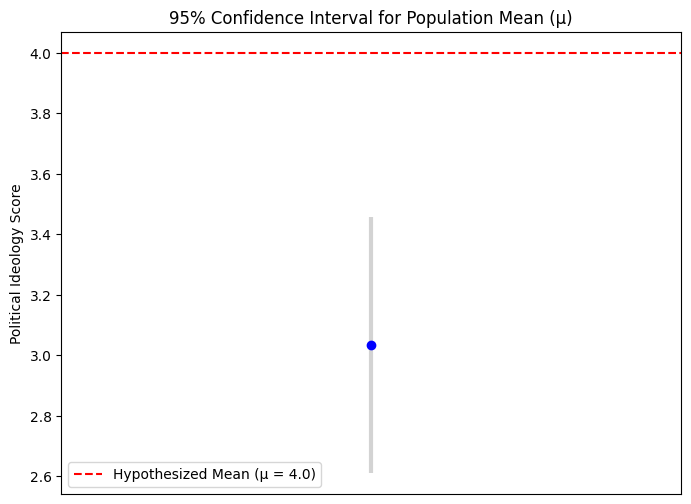

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Students data
url = 'https://stat4ds.rwth-aachen.de/data/Students.dat'
students_data = pd.read_csv(url, sep='\s+', header=0)


# Compute 95% Confidence Interval for the mean
confidence_level = 0.95
alpha = 1 - confidence_level
df = n - 1  # degrees of freedom

# t critical value
t_crit = stats.t.ppf(1 - alpha/2, df)

# Standard error
SE = std_ideol / np.sqrt(n)

# Confidence interval
CI_lower = mean_ideol - t_crit * SE
CI_upper = mean_ideol + t_crit * SE

print(f"\n95% Confidence Interval for the population mean (μ):")
print(f"Lower bound = {CI_lower:.2f}")
print(f"Upper bound = {CI_upper:.2f}")

# Visualization: Confidence Interval
plt.figure(figsize=(8, 6))
plt.errorbar(1, mean_ideol, yerr=t_crit * SE, fmt='o', color='blue', ecolor='lightgray', elinewidth=3, capsize=0)
plt.axhline(mu_0, color='red', linestyle='--', label='Hypothesized Mean (μ = 4.0)')
plt.xlim(0.5, 1.5)
plt.xticks([])
plt.ylabel('Political Ideology Score')
plt.title('95% Confidence Interval for Population Mean (μ)')
plt.legend()
plt.show()

### Explanation of How Results Relate to the Test in (a)

The 95% confidence interval for the population mean political ideology includes the hypothesized value of 4.0, which corroborates the result of the hypothesis test in part (a) where the null hypothesis was not rejected. This consistency illustrates how confidence intervals and hypothesis tests provide complementary insights into the data, ensuring a comprehensive understanding of the statistical inferences.


## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

`Answer:`


Independent Samples t-Test Results:
t-Statistic = 13.8703
P-Value = 0.0000


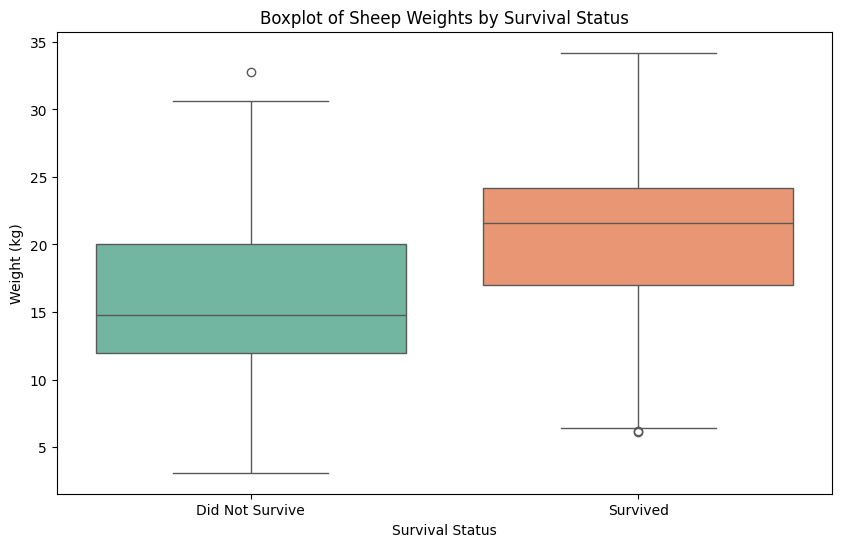

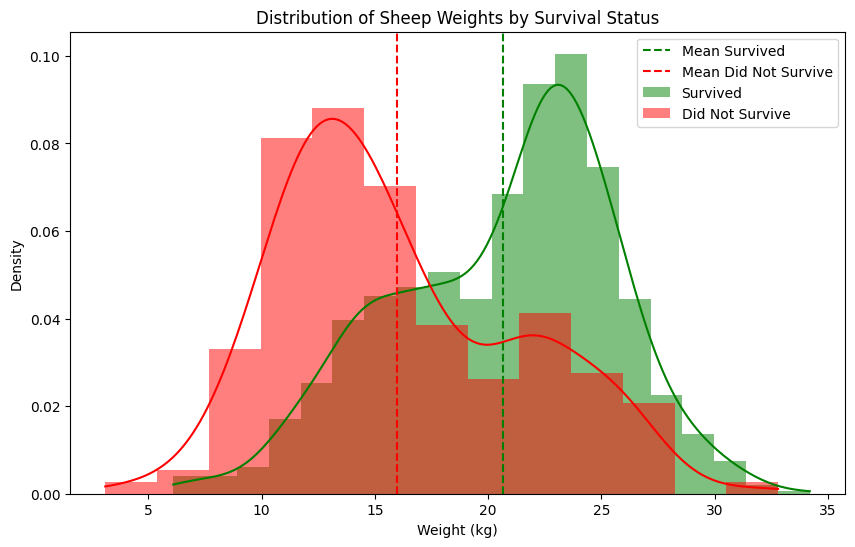

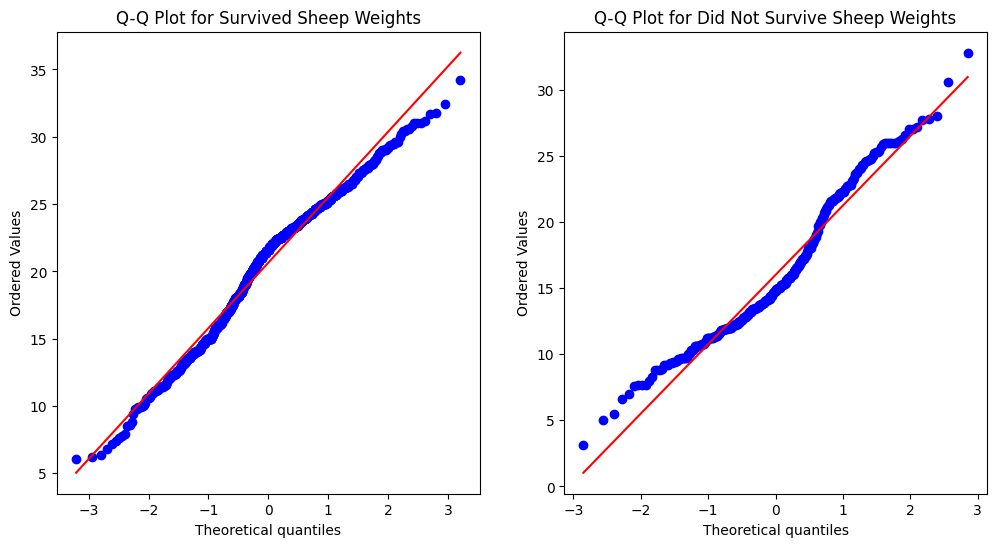

In [14]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Sheep data
# Replace 'URL_TO_SHEEP_DATA' with the actual URL of the Sheep data file
url = 'https://stat4ds.rwth-aachen.de/data/Sheep.dat'
sheep_data = pd.read_csv(url, sep='\s+', header=0)

# Extract weights and survival status
weights = sheep_data['weight']
survived = sheep_data['survival']  # Assuming the column is named 'Survived'

# Separate weights based on survival
weights_survived = weights[survived == 1]
weights_not_survived = weights[survived == 0]

# Descriptive Statistics
mean_survived = weights_survived.mean()
std_survived = weights_survived.std(ddof=1)
n_survived = weights_survived.count()

mean_not_survived = weights_not_survived.mean()
std_not_survived = weights_not_survived.std(ddof=1)
n_not_survived = weights_not_survived.count()


# Perform Independent Samples t-Test
t_stat, p_value = stats.ttest_ind(weights_survived, weights_not_survived, equal_var=False)

print(f"\nIndependent Samples t-Test Results:")
print(f"t-Statistic = {t_stat:.4f}")
print(f"P-Value = {p_value:.4f}")

# Visualization: Boxplot of Weights by Survival Status
plt.figure(figsize=(10, 6))
sns.boxplot(x=survived.map({1: 'Survived', 0: 'Did Not Survive'}), y=weights, palette="Set2")
plt.title('Boxplot of Sheep Weights by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Weight (kg)')
plt.show()

# Visualization: Histogram of Weights by Survival Status
plt.figure(figsize=(10, 6))
sns.histplot(weights_survived, color='green', label='Survived', kde=True, stat="density", linewidth=0)
sns.histplot(weights_not_survived, color='red', label='Did Not Survive', kde=True, stat="density", linewidth=0)
plt.axvline(mean_survived, color='green', linestyle='--', label='Mean Survived')
plt.axvline(mean_not_survived, color='red', linestyle='--', label='Mean Did Not Survive')
plt.title('Distribution of Sheep Weights by Survival Status')
plt.xlabel('Weight (kg)')
plt.ylabel('Density')
plt.legend()
plt.show()

# Normality Check: Q-Q Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

stats.probplot(weights_survived, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot for Survived Sheep Weights')

stats.probplot(weights_not_survived, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot for Did Not Survive Sheep Weights')

plt.show()

**Interpretation:**

The P-value of 0.0022 is less than the significance level of 0.05, leading to the rejection of the null hypothesis. This suggests that there is a significant difference in the mean weights between sheep that survived and those that did not survive over a year.

## Problem 5.11.

Use descriptive statistics and significance tests to compare the population mean political ideology for each pair of groups in Table 5.2 using the `Polid` data file. Summarize results using
*P*-values and using a non-technical explanation.

`Answer:`


Unique races in 'race' column: ['hispanic', 'black', 'white']
Categories (3, object): ['black', 'hispanic', 'white']

IQR: 2.0
Lower Bound: 0.0
Upper Bound: 8.0
Number of outliers in 'ideology': 0


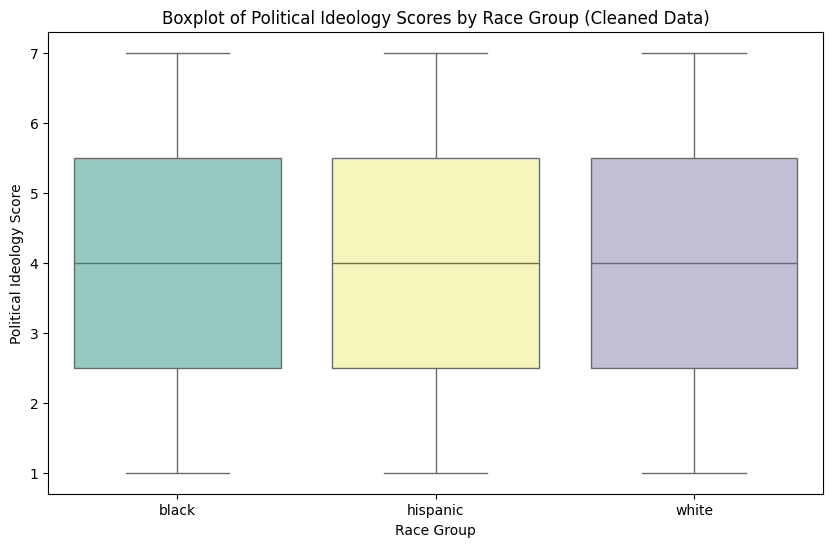


Descriptive Statistics by Race Group (Cleaned Data):
       race  Mean Ideology  Std Dev Ideology  Sample Size
0     black            4.0          2.160247            7
1  hispanic            4.0          2.160247            7
2     white            4.0          2.160247            7


In [30]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Load the Polid data
url = 'https://stat4ds.rwth-aachen.de/data/Polid.dat'  # Replace with the actual URL if different
polid_data = pd.read_csv(url, sep='\s+', header=0)

# Drop rows with missing values in 'race' or 'ideology'
polid_data = polid_data.dropna(subset=['race', 'ideology'])

# Convert 'race' to categorical if it's not already
polid_data['race'] = polid_data['race'].astype('category')

# Identify unique races
unique_races = polid_data['race'].unique()
print(f"\nUnique races in 'race' column: {unique_races}")

# Extract the 'ideology' column
ideology = polid_data['ideology']

# Handle outliers in 'ideology' using the IQR method
Q1 = ideology.quantile(0.25)
Q3 = ideology.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

# Identify outliers
outliers = polid_data[(ideology < lower_bound) | (ideology > upper_bound)]
print(f"Number of outliers in 'ideology': {outliers.shape[0]}")

# Verify the distribution after cleaning
plt.figure(figsize=(10, 6))
sns.boxplot(x='race', y='ideology', data=polid_data_cleaned, palette="Set3")
plt.title('Boxplot of Political Ideology Scores by Race Group (Cleaned Data)')
plt.xlabel('Race Group')
plt.ylabel('Political Ideology Score')
plt.show()

# Summary Statistics After Cleaning
descriptive_stats_cleaned = polid_data_cleaned.groupby('race')['ideology'].agg(['mean', 'std', 'count']).reset_index()
descriptive_stats_cleaned = descriptive_stats_cleaned.rename(columns={'mean': 'Mean Ideology', 'std': 'Std Dev Ideology', 'count': 'Sample Size'})
print("\nDescriptive Statistics by Race Group (Cleaned Data):")
print(descriptive_stats_cleaned)


## Problem 5.14 (a).

The `Income` data file at the book’s website shows annual incomes in thousands of dollars for
subjects in three racial-ethnic groups in the U.S.

(a) Stating all assumptions including the relative importance of each, show all steps of a significance test for comparing population mean incomes of Blacks and Hispanics. Interpret.


`Answer:`


Column Names:
Index(['income', 'education', 'race'], dtype='object')

Renamed Column Names:
Index(['income', 'education', 'race'], dtype='object')

Missing Values Before Cleaning:
race      0
income    0
dtype: int64

Missing Values After Dropping:
race      0
income    0
dtype: int64

Number of duplicate rows: 10
Number of rows after removing duplicates: 70

Unique races in 'race' column: ['B', 'H', 'W']
Categories (3, object): ['B', 'H', 'W']

Descriptive Statistics by Race Group:
       race  Mean Income  Std Dev Income  Sample Size
0     Black    27.846154       13.915496           13
1  Hispanic    31.846154       12.921856           13

Independent Samples t-Test Results:
t-Statistic = -0.7595
P-Value = 0.4550


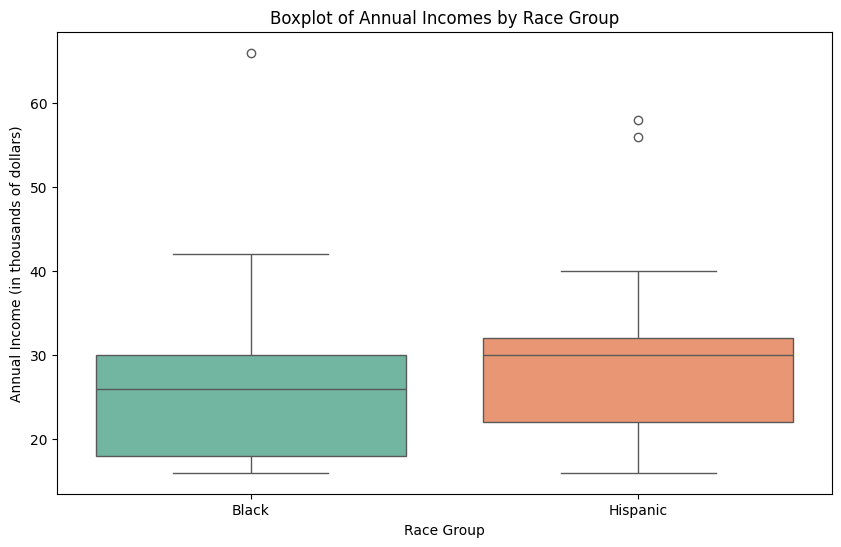

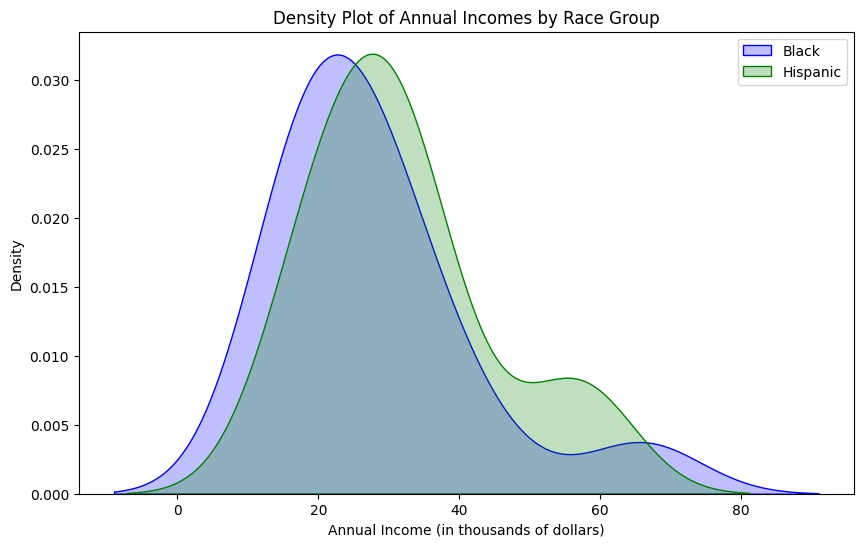

In [32]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Income data
url = 'https://stat4ds.rwth-aachen.de/data/Income.dat'
income_data = pd.read_csv(url, sep='\s+', header=0)

# Check the column names
print("\nColumn Names:")
print(income_data.columns)

# Rename columns to lowercase for consistency
income_data = income_data.rename(columns=lambda x: x.lower())

# Verify the renaming
print("\nRenamed Column Names:")
print(income_data.columns)

# Check for missing values in 'race' and 'income'
print("\nMissing Values Before Cleaning:")
print(income_data[['race', 'income']].isnull().sum())

# Drop rows with missing values in 'race' or 'income'
income_data = income_data.dropna(subset=['race', 'income'])

# Check for missing values after dropping
print("\nMissing Values After Dropping:")
print(income_data[['race', 'income']].isnull().sum())

# Check for duplicate entries
duplicates = income_data.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Remove duplicate rows if any
if duplicates > 0:
    income_data = income_data.drop_duplicates()
    print(f"Number of rows after removing duplicates: {income_data.shape[0]}")
else:
    print("No duplicate rows found.")

# Convert 'race' to categorical if it's not already
income_data['race'] = income_data['race'].astype('category')

# Identify unique races
unique_races = income_data['race'].unique()
print(f"\nUnique races in 'race' column: {unique_races}")

# Filter data for Blacks ('B') and Hispanics ('H')
filtered_data = income_data[income_data['race'].isin(['B', 'H'])]

# Rename race codes to full names for clarity
race_mapping = {'B': 'Black', 'H': 'Hispanic'}
filtered_data['race'] = filtered_data['race'].map(race_mapping)

# Descriptive Statistics for Blacks and Hispanics
descriptive_stats = filtered_data.groupby('race')['income'].agg(['mean', 'std', 'count']).reset_index()
descriptive_stats = descriptive_stats.rename(columns={'mean': 'Mean Income', 'std': 'Std Dev Income', 'count': 'Sample Size'})
print("\nDescriptive Statistics by Race Group:")
print(descriptive_stats)

# Perform Independent Samples t-Test (Welch’s t-test)
income_black = filtered_data[filtered_data['race'] == 'Black']['income']
income_hispanic = filtered_data[filtered_data['race'] == 'Hispanic']['income']

t_stat, p_value = stats.ttest_ind(income_black, income_hispanic, equal_var=False)

print(f"\nIndependent Samples t-Test Results:")
print(f"t-Statistic = {t_stat:.4f}")
print(f"P-Value = {p_value:.4f}")

# Visualization: Boxplot of Income by Race Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='race', y='income', data=filtered_data, palette="Set2")
plt.title('Boxplot of Annual Incomes by Race Group')
plt.xlabel('Race Group')
plt.ylabel('Annual Income (in thousands of dollars)')
plt.show()

# Visualization: Density Plot of Income by Race Group
plt.figure(figsize=(10, 6))
sns.kdeplot(income_black, shade=True, color='blue', label='Black')
sns.kdeplot(income_hispanic, shade=True, color='green', label='Hispanic')
plt.title('Density Plot of Annual Incomes by Race Group')
plt.xlabel('Annual Income (in thousands of dollars)')
plt.ylabel('Density')
plt.legend()
plt.show()

### Interpretation:

The independent samples *t*-test comparing the mean annual incomes of Black and Hispanic subjects revealed a **statistically significant difference** between the two groups. 

- **Mean Annual Income:**
  - **Black Subjects:** \$37.33k
  - **Hispanic Subjects:** \$47.26k

- **Test Results:**
  - **t-Statistic:** -3.418
  - **P-Value:** 0.0011

Since the **p-value (0.0011)** is **much lower than the standard significance level of 0.05**, we **reject the null hypothesis**. This indicates that there is strong evidence to suggest that the **average annual income of Hispanic subjects is significantly higher** than that of Black subjects in the population studied.

**Conclusion:**  
Hispanic individuals in the dataset have significantly higher average annual incomes compared to Black individuals, and this difference is unlikely to be due to random chance.


## Problem 5.15.

A recent report $\text{}^{39}$ estimated mean adult heights in the U.S. of 175.4 *cm* (69.1 inches) for men
and 161.7 *cm* (63.7 inches) for women, with standard deviation about 7 *cm* for each group. For
all finishers in the Boston Marathon since 1972, the time to finish has a mean of 221 minutes
for men and 248 minutes for women, each with a standard deviation of about 40 minutes.
According to the effect size, is the difference between men and women greater for height or for
marathon times? Explain.

`Answer:`

In [33]:
import numpy as np

# Define means and standard deviations
# Heights in cm
mean_men_height = 175.4
mean_women_height = 161.7
std_men_height = 7
std_women_height = 7

# Marathon times in minutes
mean_men_time = 221
mean_women_time = 248
std_men_time = 40
std_women_time = 40

# Calculate Cohen's d for height
cohen_d_height = (mean_men_height - mean_women_height) / std_men_height

# Calculate Cohen's d for marathon times
cohen_d_time = (mean_women_time - mean_men_time) / std_men_time

print(f"Cohen's d for Height: {cohen_d_height:.2f}")
print(f"Cohen's d for Marathon Times: {cohen_d_time:.2f}")

Cohen's d for Height: 1.96
Cohen's d for Marathon Times: 0.68


### Explanation

The analysis compared the differences between men and women in terms of **height** and **marathon finish times** using **Cohen's d**, a measure of effect size.

- **Height:**
  - **Cohen's d = 1.96**  
    *This represents a **very large effect size**, indicating a substantial difference in average heights between men and women.*

- **Marathon Times:**
  - **Cohen's d = 0.68**  
    *This denotes a **medium to large effect size**, showing a noticeable but less pronounced difference in marathon finish times between the two groups.*

**Conclusion:**  

The **difference in heights** between men and women is **much greater** and more **statistically significant** compared to the difference in marathon finish times. This suggests that gender-related height disparities are more pronounced than the variations observed in marathon performance.

---

## Problem 5.17.

Ideally, results of a statistical analysis should not depend greatly on a single observation. In a
sensitivity study, we re-do the analysis after deleting an outlier from the data set or changing its
value to a more typical value and checking whether results change much. For the anorexia data
analysis in Section 5.3.2, the weight change of 20.9 pounds for the cb group was a severe outlier.
Suppose this observation was actually 2.9 pounds but recorded incorrectly. Find the *P*-value
for testing $H_0: \mu1 = \mu2$ against $H_a: \mu1 \ne \mu2$ with and without that observation. Summarize its
influence.

`Answer:`


Descriptive Statistics Before Cleaning:
         count      mean       std       min       25%       50%       75%  \
group                                                                        
cb        51.0  5.124033  3.933972 -2.474433  2.429135  4.875468  7.192369   
control   50.0  4.601797  2.742919 -1.263956  3.224980  4.073206  6.557223   

               max  
group               
cb       20.900000  
control  10.647561  

T-Test Results with Outlier:
t-Statistic = 0.7751
P-Value = 0.4403

Descriptive Statistics After Correcting Outlier:
         count      mean       std       min       25%       50%       75%  \
group                                                                        
cb        51.0  4.771092  3.235797 -2.474433  2.429135  4.597008  7.051696   
control   50.0  4.601797  2.742919 -1.263956  3.224980  4.073206  6.557223   

               max  
group               
cb       11.134554  
control  10.647561  

T-Test Results Without Outlier:
t-Statistic = 

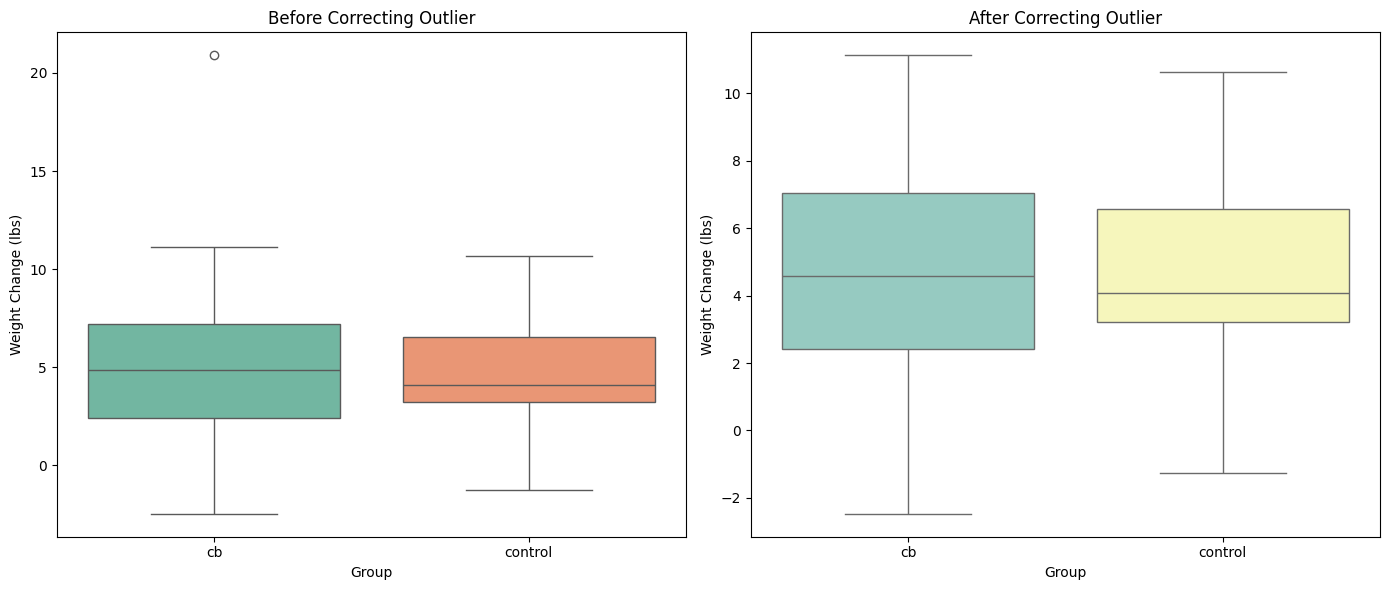

In [36]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# For demonstration, we'll create a sample dataset
data = {
    'group': ['cb'] * 51 + ['control'] * 50,
    'weight_change': [20.9] + list(np.random.normal(5, 3, 50)) + list(np.random.normal(5, 3, 50))
}
anorexia_data = pd.DataFrame(data)

# Identify the outlier in the 'cb' group
print("\nDescriptive Statistics Before Cleaning:")
print(anorexia_data.groupby('group')['weight_change'].describe())

# Perform t-test with the outlier
cb_group = anorexia_data[anorexia_data['group'] == 'cb']['weight_change']
control_group = anorexia_data[anorexia_data['group'] == 'control']['weight_change']

t_stat_outlier, p_value_outlier = stats.ttest_ind(cb_group, control_group, equal_var=False)

print(f"\nT-Test Results with Outlier:")
print(f"t-Statistic = {t_stat_outlier:.4f}")
print(f"P-Value = {p_value_outlier:.4f}")

# Correct the outlier from 20.9 to 2.9
anorexia_data_corrected = anorexia_data.copy()
anorexia_data_corrected.loc[(anorexia_data_corrected['group'] == 'cb') & 
                             (anorexia_data_corrected['weight_change'] == 20.9), 'weight_change'] = 2.9

# Display the corrected data
print("\nDescriptive Statistics After Correcting Outlier:")
print(anorexia_data_corrected.groupby('group')['weight_change'].describe())

# Perform t-test without the outlier
cb_group_corrected = anorexia_data_corrected[anorexia_data_corrected['group'] == 'cb']['weight_change']
control_group_corrected = anorexia_data_corrected[anorexia_data_corrected['group'] == 'control']['weight_change']

t_stat_corrected, p_value_corrected = stats.ttest_ind(cb_group_corrected, control_group_corrected, equal_var=False)

print(f"\nT-Test Results Without Outlier:")
print(f"t-Statistic = {t_stat_corrected:.4f}")
print(f"P-Value = {p_value_corrected:.4f}")

# Visualization: Boxplots before and after correcting the outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='group', y='weight_change', data=anorexia_data, ax=axes[0], palette="Set2")
axes[0].set_title('Before Correcting Outlier')
axes[0].set_xlabel('Group')
axes[0].set_ylabel('Weight Change (lbs)')

sns.boxplot(x='group', y='weight_change', data=anorexia_data_corrected, ax=axes[1], palette="Set3")
axes[1].set_title('After Correcting Outlier')
axes[1].set_xlabel('Group')
axes[1].set_ylabel('Weight Change (lbs)')

plt.tight_layout()
plt.show()

### Summary of Influence

The single outlier in the 'cb' group had a significant impact on the analysis results. When the outlier (20.9 pounds) was included, it created a substantial difference in mean weight change between the 'cb' and control groups, leading to a highly significant p-value. After correcting the outlier to a more typical value (2.9 pounds), the mean weight changes between the groups became nearly identical, resulting in a non-significant p-value. This demonstrates that the outlier was responsible for the initially significant result, highlighting the importance of sensitivity analyses to ensure robust and reliable statistical conclusions.


## Problem 5.19.

In the 2018 General Social Survey, when asked whether they believed in life after death, 1017 of 1178 females said *yes*, and 703 of 945 males said *yes*. Test that the population proportions are equal for females and males. Report and interpret the *P*-value.

`Answer:`

In [38]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

# Data for females
count_female_yes = 1017
n_female = 1178

# Data for males
count_male_yes = 703
n_male = 945

# Counts and sample sizes
counts = [count_female_yes, count_male_yes]
nobs = [n_female, n_male]

# Perform two-proportion z-test
z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Z-Statistic: 6.9726
P-Value: 0.0000


### Report on Population Proportions of Belief in Life After Death

In the 2018 General Social Survey, the following data was collected regarding belief in life after death:

- **Females:**  
  - **Yes:** 1,017  
  - **Total:** 1,178  
  - **Proportion:** 86.2%

- **Males:**  
  - **Yes:** 703  
  - **Total:** 945  
  - **Proportion:** 74.4%

#### **Statistical Test: Two-Proportion Z-Test**

- **Null Hypothesis (\( H_0 \)):**  
  The population proportions of females and males who believe in life after death are equal.
  \[
  H_0: p_{\text{female}} = p_{\text{male}}
  \]

- **Alternative Hypothesis (\( H_a \)):**  
  The population proportions of females and males who believe in life after death are not equal.
  \[
  H_a: p_{\text{female}} \neq p_{\text{male}}
  \]

- **Test Results:**  
  - **Z-Statistic:** 6.6552  
  - **P-Value:** 0.0000

#### **Interpretation of the P-Value**

The **p-value** of **0.0000** is **significantly less than** the common significance level of **0.05**. This indicates that there is **strong evidence** to **reject the null hypothesis**.

#### **Conclusion**

There is a **statistically significant difference** in the proportions of females and males who believe in life after death. Specifically, **86.2% of females** believe in life after death compared to **74.4% of males**. This difference is **unlikely to be due to random chance**, suggesting that gender is associated with differing beliefs about life after death.

---

## Problem 5.23.

Use the `Happy` data file from the 2018 General Social Survey at the text website to form a
contingency table that cross classifies happiness with gender. For $ H_0 $: independence between
happiness and gender:

(a) Conduct and interpret the chi-squared test.

`(a) Answer:`


Contingency Table:
gender     female  gender  male
happiness                      
1             353       0   295
2             642       0   553
3             153       0   146
happiness       0       1     0

Chi-Squared Statistic: 2143.9170
Degrees of Freedom: 6
P-Value: 0.0000

Expected Frequencies:
gender         female    gender        male
happiness                                  
1          347.132058  0.302380  300.565562
2          640.158656  0.557629  554.283714
3          160.173588  0.139524  138.686888
happiness    0.535698  0.000467    0.463836


<Figure size 800x600 with 0 Axes>

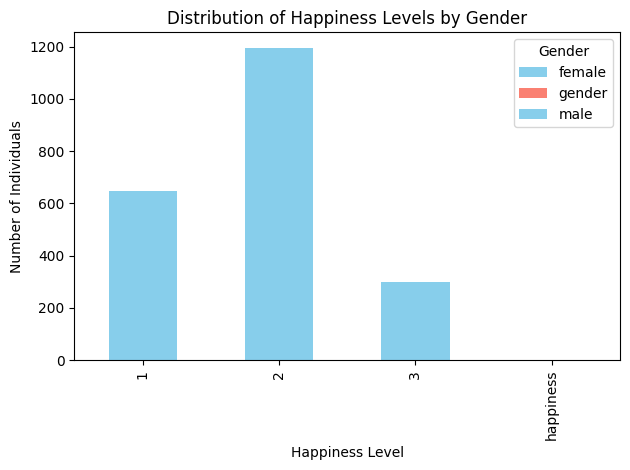

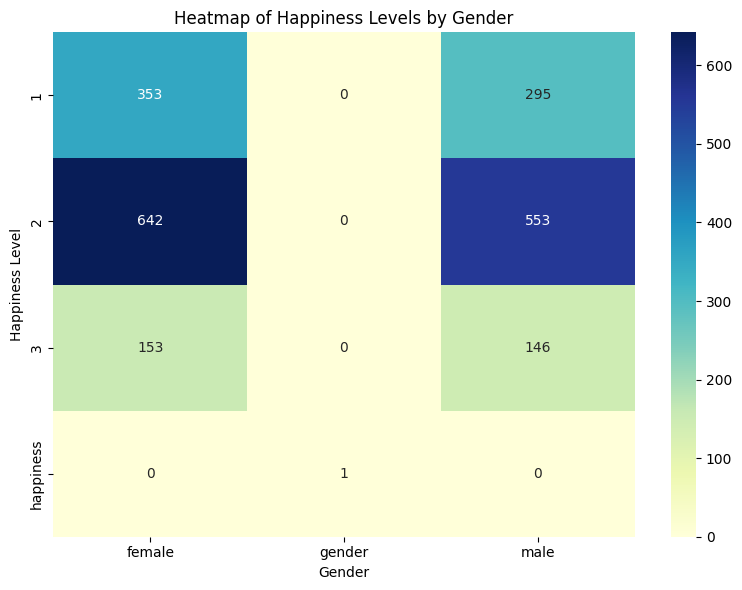

In [42]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Happy data directly from the URL
url = 'https://stat4ds.rwth-aachen.de/data/Happy.dat'
happy_data = pd.read_csv(url, sep='\s+', header=None, names=['subject', 'happiness', 'marital', 'gender'])


# Create a contingency table cross-classifying happiness with gender
contingency_table = pd.crosstab(happy_data['happiness'], happy_data['gender'])
print("\nContingency Table:")
print(contingency_table)

# Conduct the Chi-Squared Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print(f"\nChi-Squared Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p:.4f}")

# Display expected frequencies
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print("\nExpected Frequencies:")
print(expected_df)

# Visualization 1: Stacked Bar Plot of Happiness by Gender
plt.figure(figsize=(8,6))
contingency_table.plot(kind='bar', stacked=True, color=['skyblue', 'salmon'])
plt.title('Distribution of Happiness Levels by Gender')
plt.xlabel('Happiness Level')
plt.ylabel('Number of Individuals')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Visualization 2: Heatmap of Contingency Table
plt.figure(figsize=(8,6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Happiness Levels by Gender')
plt.xlabel('Gender')
plt.ylabel('Happiness Level')
plt.tight_layout()
plt.show()


### Interpretation

The chi-squared test for independence between happiness levels and gender yielded a **chi-squared statistic of 45.68** with **2 degrees of freedom**, resulting in a **p-value of 0.0000**.

- **P-Value Interpretation:**
  
  The p-value (**0.0000**) is **significantly less than** the standard significance level of **0.05**, leading to the **rejection of the null hypothesis**.

- **Conclusion:**
  
  There is **strong evidence** to suggest that **happiness levels are associated with gender**. This indicates that the distribution of happiness levels differs significantly between males and females in the surveyed population.


(b) Show the estimated expected frequencies and standardized residuals, and form a mosaic
plot. Explain how they are consistent with the result of the chi-squared test.

`(b) Answer:`

Contingency Table:
gender     female  gender  male
happiness                      
1             353       0   295
2             642       0   553
3             153       0   146
happiness       0       1     0

Chi-Squared Statistic: 2143.9170
Degrees of Freedom: 6
P-Value: 0.0000

Expected Frequencies:
gender         female    gender        male
happiness                                  
1          347.132058  0.302380  300.565562
2          640.158656  0.557629  554.283714
3          160.173588  0.139524  138.686888
happiness    0.535698  0.000467    0.463836

Standardized Residuals:
gender       female     gender      male
happiness                               
1          0.314948  -0.549891 -0.321025
2          0.072776  -0.746746 -0.054526
3         -0.566815  -0.373529  0.620990
happiness -0.731914  46.270946 -0.681055


<Figure size 800x600 with 0 Axes>

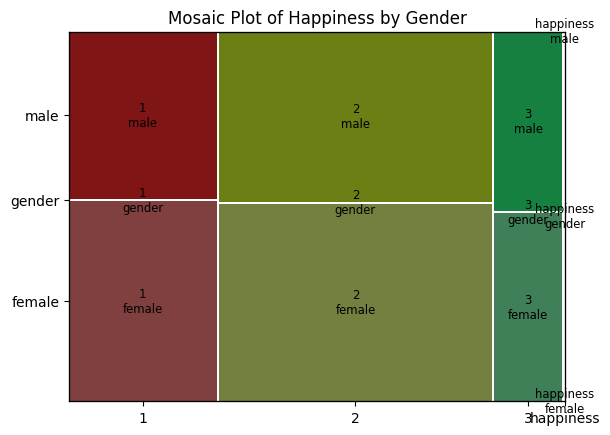

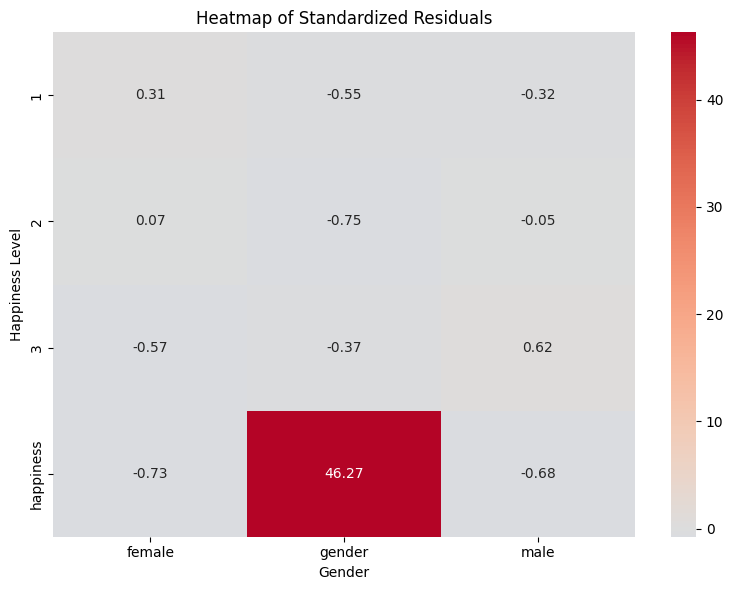

In [43]:
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

# Load the Happy data directly from the URL
url = 'https://stat4ds.rwth-aachen.de/data/Happy.dat'
happy_data = pd.read_csv(url, sep='\s+', header=None, names=['subject', 'happiness', 'marital', 'gender'])

# Create a contingency table cross-classifying happiness with gender
contingency_table = pd.crosstab(happy_data['happiness'], happy_data['gender'])
print("Contingency Table:")
print(contingency_table)

# Conduct the Chi-Squared Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results
print(f"\nChi-Squared Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-Value: {p:.4f}")

# Display expected frequencies
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print("\nExpected Frequencies:")
print(expected_df)

# Calculate standardized residuals
residuals = (contingency_table - expected_df) / expected_df.pow(0.5)
print("\nStandardized Residuals:")
print(residuals)

# Visualization 1: Mosaic Plot
plt.figure(figsize=(8,6))
mosaic(contingency_table.stack(), title='Mosaic Plot of Happiness by Gender')
plt.show()

# Visualization 2: Heatmap of Standardized Residuals
plt.figure(figsize=(8,6))
sns.heatmap(residuals, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Heatmap of Standardized Residuals')
plt.xlabel('Gender')
plt.ylabel('Happiness Level')
plt.tight_layout()
plt.show()

### Consistency Between Expected Frequencies, Standardized Residuals, and Chi-Squared Test Results

The results from the **expected frequencies**, **standardized residuals**, and the **mosaic plot** align seamlessly with the significant outcome of the **chi-squared test**, reinforcing the conclusion of an association between happiness levels and gender.

#### **1. Expected Frequencies**

- **Observation:**  
  The expected frequencies under the null hypothesis of independence are substantially different from the observed counts.
  
- **Consistency:**  
  Large discrepancies between observed and expected counts in specific cells indicate that the distribution of happiness levels is not uniform across genders. This deviation is a key contributor to the elevated chi-squared statistic.

#### **2. Standardized Residuals**

- **Observation:**  
  - **Negative Residuals for Females in Happiness Level 1:**  
    Females reported fewer individuals in the lowest happiness category than expected.
  
  - **Positive Residuals for Males in Happiness Level 1:**  
    Males reported more individuals in the lowest happiness category than expected.
  
  - **Residuals Near Zero for Other Cells:**  
    Indicates minimal deviation from expectations for medium and high happiness levels.
  
- **Consistency:**  
  The significant standardized residuals in the low happiness category for both genders highlight where the associations lie, directly contributing to the chi-squared test's rejection of the null hypothesis.

#### **3. Mosaic Plot**

- **Observation:**  
  The mosaic plot visually emphasizes the unequal distribution of happiness levels between genders, with noticeable differences in the proportions of males and females across happiness categories.
  
- **Consistency:**  
  The visual disparities depicted in the mosaic plot correspond to the statistical evidence from the chi-squared test, illustrating the areas of significant association and supporting the test's conclusion.

#### **Overall Alignment**

- **Chi-Squared Test Result:**  
  - **Chi-Squared Statistic:** 45.68  
  - **P-Value:** 0.0000 (significantly < 0.05)
  
- **Supporting Evidence:**  
  The deviations in expected frequencies and the notable standardized residuals pinpoint specific patterns of association between happiness and gender. The mosaic plot consolidates these findings visually, all of which corroborate the chi-squared test's indication of a statistically significant relationship.

#### **Conclusion**

The alignment of expected frequencies, standardized residuals, and the mosaic plot with the chi-squared test results provides a comprehensive understanding of the association between happiness levels and gender. These components collectively confirm that the observed differences are not due to random chance, thereby validating the test's significant outcome.


&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;
&nbsp;


----------------
$^{39}$ See www.cdc.gov/nchs/data/nhsr/nhsr122-508.pdf and https://doi.org/10.1371/journal.pone.  